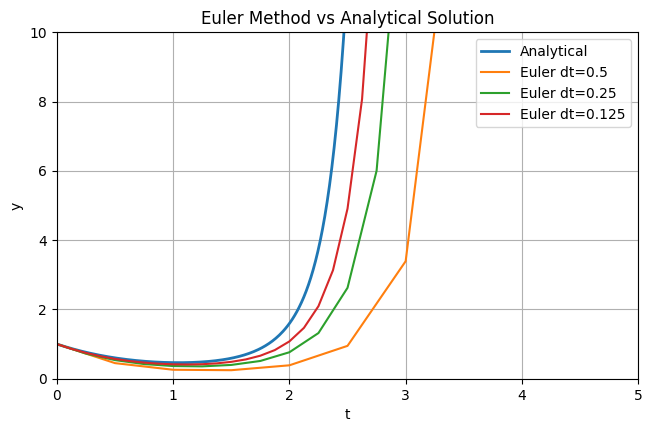

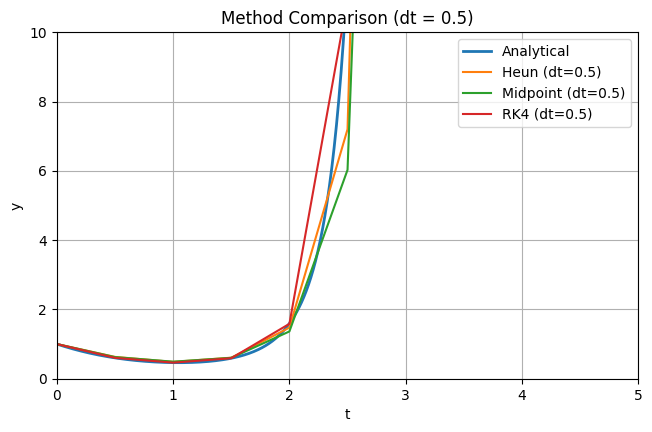

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ================= USER INPUT =================
def f(t, y):
    return y*t**2-1.1*y  # dy/dt = f(t,y)

def analytical(t):
    return np.exp((t**3)/3-1.1*t)  # exact solution

t0 = 0
y0 = 1
t_end = 5

dt_list = [0.5, 0.25, 0.125]  # time steps to compare
dt_compare = 0.5  # for method comparison


# ================= METHODS =================
def euler(F,x,y,xStop,h):
    X = []
    Y = []
    X.append(x)
    Y.append(y)
    while x < xStop:
        h = min(h,xStop - x)
        y = y + h*F(x,y)
        x = x + h
        X.append(x)
        Y.append(y)
    return np.array(X),np.array(Y)


def heun(f, t0, y0, t_end, dt):
    t_vals = np.arange(t0, t_end + dt, dt)
    y_vals = np.zeros_like(t_vals)
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        k1 = f(t_vals[i], y_vals[i])
        y_predict = y_vals[i] + dt * k1
        k2 = f(t_vals[i] + dt, y_predict)
        y_vals[i + 1] = y_vals[i] + (dt / 2) * (k1 + k2)

    return t_vals, y_vals


def midpoint(f, t0, y0, t_end, dt):
    t_vals = np.arange(t0, t_end + dt, dt)
    y_vals = np.zeros_like(t_vals)
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        k1 = f(t_vals[i], y_vals[i])
        k2 = f(t_vals[i] + dt / 2, y_vals[i] + dt / 2 * k1)
        y_vals[i + 1] = y_vals[i] + dt * k2

    return t_vals, y_vals


def rk4(f, t0, y0, t_end, dt):
    t_vals = np.arange(t0, t_end + dt, dt)
    y_vals = np.zeros_like(t_vals)
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        y = y_vals[i]

        k1 = f(t, y)
        k2 = f(t + dt / 2, y + dt / 2 * k1)
        k3 = f(t + dt / 2, y + dt / 2 * k2)
        k4 = f(t + dt, y + dt * k3)

        y_vals[i + 1] = y + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t_vals, y_vals


#PLOT 1: EULER and analytical
t_fine = np.linspace(t0, t_end, 500)
plt.figure(figsize=(7.5,4.5))

plt.plot(t_fine, analytical(t_fine), label="Analytical", linewidth=2)

for dt in dt_list:
    t_vals, y_vals = euler(f, t0, y0, t_end, dt)
    plt.plot(t_vals, y_vals, label=f"Euler dt={dt}")

plt.xlabel("t")
plt.ylabel("y")
plt.ylim(0,10)
plt.xlim(0,5)
plt.title("Euler Method vs Analytical Solution")
plt.legend()
plt.grid()

# ================= PLOT 2: METHOD COMPARISON =================
plt.figure(figsize=(7.5,4.5))

plt.plot(t_fine, analytical(t_fine), label="Analytical", linewidth=2)

t_h, y_h = heun(f, t0, y0, t_end, dt_compare)
t_m, y_m = midpoint(f, t0, y0, t_end, dt_compare)
t_rk, y_rk = rk4(f, t0, y0, t_end, dt_compare)

plt.plot(t_h, y_h, label="Heun (dt=0.5)")
plt.plot(t_m, y_m, label="Midpoint (dt=0.5)")
plt.plot(t_rk, y_rk, label="RK4 (dt=0.5)")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Method Comparison (dt = 0.5)")
plt.legend()
plt.grid()
plt.ylim(0,10)
plt.xlim(0,5)

plt.show()

In [21]:
import numpy as np

# ODE: y' = x^2 - 4y
def f(x, y):
    return x**2 - 4*y

# RK2 (midpoint) single step
def rk2_step(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + (h/2)*k1)
    return y + h * k2

#RK4
def rk4_step(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + h/2 * k1)
    k3 = f(x + h/2, y + h/2 * k2)
    k4 = f(x + h, y + h * k3)

    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# initial condition
x = 0.0
y = 1.0
h = 0.15  # step size

# take 2 steps to reach x = 0.3
for _ in range(2):
    y = rk2_step(f, x, y, h)
    x += h

print(f"y_R2K(0.3) = {y:.6f}")

#Initial again
x = 0.0
y = 1.0
h = 0.3
y = rk4_step(f, x, y, h)
print(f"y_R4K(0.3) = {y:.6f}")

y_exact = 31/32*np.exp(-4*0.3)+1/4*h**2-1/8*h+1/32
print(f"y_exact(0.3) = {y_exact:.6f}")


y_R2K(0.3) = 0.343471
y_R4K(0.3) = 0.325510
y_exact(0.3) = 0.308032


In [22]:
## module euler
''' X,Y = integrate(F,x,y,xStop,h).
    Euler's method for solving the
    initial value problem {y}' = {F(x,{y})}, where
    {y} = {y[0],y[1],...y[n-1]}.
    x,y   = initial conditions
    xStop = terminal value of x
    h     = increment of x used in integration
    F     = user-supplied function that returns the
            array F(x,y) = {y'[0],y'[1],...,y'[n-1]}.
'''
import numpy as np
def integrate(F,x,y,xStop,h):
    X = []
    Y = []
    X.append(x)
    Y.append(y)
    while x < xStop:
        h = min(h,xStop - x)
        y = y + h*F(x,y)
        x = x + h
        X.append(x)
        Y.append(y)
    return np.array(X),np.array(Y)
def F(t, y):
    return np.sin(y)  # dy/dt = f(t,y)

h=0.1
x0 = 0
y0 = 1
x_stop = 0.5
X, Y = integrate(F, x0, y0, x_stop, h)

print("y_euler(0.5) =", Y[-1])
print(f"y_R2K = 1.4664")


y_euler(0.5) = 1.457851197132088
y_R2K = 1.4664


h_stable = 0.2


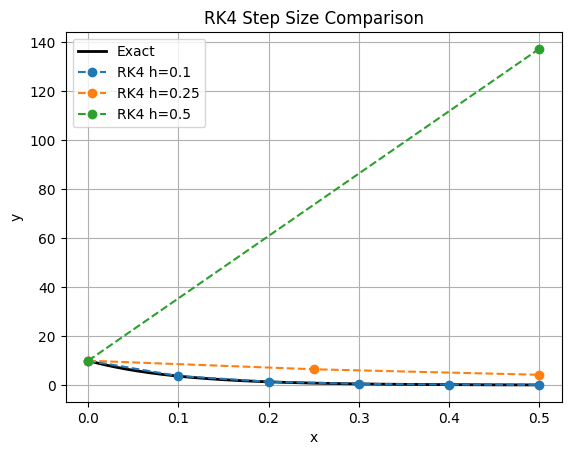

Massive instability is observed with h=0.5, with better approximations as h goes below 0.2


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(x, y):
    return x - 10*y

lamda_max = 10
h_stable = 2/lamda_max
print(f"h_stable = {h_stable}")

# analytical solution (given)
def y_exact(x):
    return 0.1*x - 0.001 + 10.01*np.exp(-10*x)

## module run_kut4
''' X,Y = integrate(F,x,y,xStop,h).
    4th-order Runge-Kutta method for solving the
    initial value problem {y}' = {F(x,{y})}, where
    {y} = {y[0],y[1],...y[n-1]}.
    x,y   = initial conditions
    xStop = terminal value of x
    h     = increment of x used in integration
    F     = user-supplied function that returns the
            array F(x,y) = {y'[0],y'[1],...,y'[n-1]}.
'''
import numpy as np
def integrate(F,x,y,xStop,h):

    def run_kut4(F,x,y,h):
        K0 = h*F(x,y)
        K1 = h*F(x + h/2.0, y + K0/2.0)
        K2 = h*F(x + h/2.0, y + K1/2.0)
        K3 = h*F(x + h, y + K2)
        return (K0 + 2.0*K1 + 2.0*K2 + K3)/6.0

    X = []
    Y = []
    X.append(x)
    Y.append(y)
    while x < xStop:
        h = min(h,xStop - x)
        y = y + run_kut4(F,x,y,h)
        x = x + h
        X.append(x)
        Y.append(y)
    return np.array(X),np.array(Y)

# settings
x0 = 0.0
y0 = 10.0
xEnd = 0.5

h_values = [0.1, 0.25, 0.5]

# fine grid for exact solution
x_fine = np.linspace(x0, xEnd, 500)

plt.figure()

# exact solution
plt.plot(x_fine, y_exact(x_fine), 'k', linewidth=2, label="Exact")

# RK4 runs
for h in h_values:
    X, Y = rk4(f, x0, y0, xEnd, h)
    plt.plot(X, Y, 'o--', label=f"RK4 h={h}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("RK4 Step Size Comparison")
plt.grid()
plt.legend()

plt.show()
print("Massive instability is observed with h=0.5, with better approximations as h goes below 0.2")